In [7]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
    classification_report
)

In [8]:
START_DATE = "2010-01-01"
END_DATE = "2025-01-01"

sp500 = yf.download(
    "^GSPC",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=False
)

print(sp500.shape)
print(sp500.index.min())
print(sp500.index.max())
print(sp500.isna().sum())

[*********************100%***********************]  1 of 1 completed

(3774, 6)
2010-01-04 00:00:00
2024-12-31 00:00:00
Price      Ticker
Adj Close  ^GSPC     0
Close      ^GSPC     0
High       ^GSPC     0
Low        ^GSPC     0
Open       ^GSPC     0
Volume     ^GSPC     0
dtype: int64


In [9]:
sp500.columns = sp500.columns.get_level_values(0)

print(sp500.columns)
sp500.head()

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2010-01-04,1132.989990,1132.989990,1133.869995,1116.560059,1116.560059,3991400000
2010-01-05,1136.520020,1136.520020,1136.630005,1129.660034,1132.660034,2491020000
2010-01-06,1137.140015,1137.140015,1139.189941,1133.949951,1135.709961,4972660000
2010-01-07,1141.689941,1141.689941,1142.459961,1131.319946,1136.270020,5270680000
2010-01-08,1144.979980,1144.979980,1145.390015,1136.219971,1140.520020,4389590000


calculer le rendement journalier

In [10]:
sp500["log_return"] = np.log(
    sp500["Close"] / sp500["Close"].shift(1)
)

sp500[["Close", "log_return"]].head(10)

Price,Close,log_return
Date,,
2010-01-04,1132.989990,NaN
2010-01-05,1136.520020,0.003111
2010-01-06,1137.140015,0.000545
2010-01-07,1141.689941,0.003993
2010-01-08,1144.979980,0.002878
2010-01-11,1146.979980,0.001745
2010-01-12,1136.219971,-0.009425
2010-01-13,1145.680054,0.008291
2010-01-14,1148.459961,0.002423


créer les features basées sur le passé

In [11]:
# Feature 1: today's return
sp500["return_1d"] = sp500["log_return"]

# Feature 2: cumulative return over the past 5 trading days
sp500["momentum_5d"] = (
    sp500["log_return"]
    .rolling(window=5)
    .sum()
)

# Feature 3: realized volatility over the past 5 trading days
sp500["past_vol_5d"] = np.sqrt(
    sp500["log_return"]
    .pow(2)
    .rolling(window=5)
    .sum()
    * (252 / 5)
)

sp500[
    ["return_1d", "momentum_5d", "past_vol_5d"]
].head(12)

Price,return_1d,momentum_5d,past_vol_5d
Date,,,
2010-01-04,NaN,NaN,NaN
2010-01-05,0.003111,NaN,NaN
2010-01-06,0.000545,NaN,NaN
2010-01-07,0.003993,NaN,NaN
2010-01-08,0.002878,NaN,NaN
2010-01-11,0.001745,0.012272,0.043327
2010-01-12,-0.009425,-0.000264,0.076596
2010-01-13,0.008291,0.007482,0.096524
2010-01-14,0.002423,0.005912,0.093858


créer la volatilité future sur 5 jours

In [12]:
# Squared returns from t+1 onward
future_squared_returns = (
    sp500["log_return"]
    .shift(-1)
    .pow(2)
)

# Future realized volatility over the next 5 trading days
sp500["future_vol_5d"] = np.sqrt(
    future_squared_returns
    .rolling(window=5)
    .sum()
    .shift(-4)
    * (252 / 5)
)

sp500[
    ["log_return", "past_vol_5d", "future_vol_5d"]
].head(15)

Price,log_return,past_vol_5d,future_vol_5d
Date,,,
2010-01-04,NaN,NaN,0.043327
2010-01-05,0.003111,NaN,0.076596
2010-01-06,0.000545,NaN,0.096524
2010-01-07,0.003993,NaN,0.093858
2010-01-08,0.002878,NaN,0.119835
2010-01-11,0.001745,0.043327,0.148270
2010-01-12,-0.009425,0.076596,0.152407
2010-01-13,0.008291,0.096524,0.195450
2010-01-14,0.002423,0.093858,0.251337


créer les trois périodes temporelles

In [13]:
H = 5

train_raw = sp500.loc["2010-01-01":"2020-12-31"].copy()
val_raw   = sp500.loc["2021-01-01":"2022-12-31"].copy()
test_raw  = sp500.loc["2023-01-01":"2024-12-31"].copy()

print("Train:", train_raw.shape)
print("Validation:", val_raw.shape)
print("Test:", test_raw.shape)

Train: (2769, 11)
Validation: (503, 11)
Test: (502, 11)


appliquer l’embargo de 5 jours
Maintenant on retire les 5 dernières observations du train et de la validation, pour éviter que leur future_vol_5d utilise des rendements appartenant à la période suivante.

In [14]:
train_raw = train_raw.iloc[:-H].copy()
val_raw   = val_raw.iloc[:-H].copy()

print(
    "Train:",
    train_raw.index.min(),
    train_raw.index.max(),
    train_raw.shape
)

print(
    "Validation:",
    val_raw.index.min(),
    val_raw.index.max(),
    val_raw.shape
)

print(
    "Test:",
    test_raw.index.min(),
    test_raw.index.max(),
    test_raw.shape
)

Train: 2010-01-04 00:00:00 2020-12-23 00:00:00 (2764, 11)
Validation: 2021-01-04 00:00:00 2022-12-22 00:00:00 (498, 11)
Test: 2023-01-03 00:00:00 2024-12-31 00:00:00 (502, 11)


calculer le seuil high-volatility uniquement sur le train

In [15]:
high_vol_threshold = (
    train_raw["future_vol_5d"]
    .dropna()
    .quantile(0.67)
)

print("High volatility threshold:", high_vol_threshold)

High volatility threshold: 0.14394440555637616


créer correctement le label high_vol

In [16]:
sp500["high_vol"] = (
    (sp500["future_vol_5d"] > high_vol_threshold)
    .astype(float)
    .where(sp500["future_vol_5d"].notna())
)

sp500[
    ["future_vol_5d", "high_vol"]
].tail(10)

Price,future_vol_5d,high_vol
Date,,
2024-12-17,0.244605,1.0
2024-12-18,0.121128,0.0
2024-12-19,0.144441,1.0
2024-12-20,0.144250,1.0
2024-12-23,0.138132,0.0
2024-12-24,NaN,NaN
2024-12-26,NaN,NaN
2024-12-27,NaN,NaN
2024-12-30,NaN,NaN


construire le dataset propre

In [17]:
feature_cols = [
    "return_1d",
    "momentum_5d",
    "past_vol_5d"
]

model_data = sp500[
    feature_cols + ["future_vol_5d", "high_vol"]
].dropna().copy()

print("Clean dataset shape:", model_data.shape)

model_data.head()

Clean dataset shape: (3764, 5)


Price,return_1d,momentum_5d,past_vol_5d,future_vol_5d,high_vol
Date,,,,,
2010-01-11,0.001745,0.012272,0.043327,0.148270,1.0
2010-01-12,-0.009425,-0.000264,0.076596,0.152407,1.0
2010-01-13,0.008291,0.007482,0.096524,0.195450,1.0
2010-01-14,0.002423,0.005912,0.093858,0.251337,1.0
2010-01-15,-0.010882,-0.007847,0.119835,0.241376,1.0


recréer les splits propres avec l’embargo

In [18]:
H = 5

train = model_data.loc["2010-01-01":"2020-12-31"].iloc[:-H].copy()
val   = model_data.loc["2021-01-01":"2022-12-31"].iloc[:-H].copy()
test  = model_data.loc["2023-01-01":"2024-12-31"].copy()

print(
    "Train:",
    train.shape,
    train.index.min(),
    train.index.max()
)

print(
    "Validation:",
    val.shape,
    val.index.min(),
    val.index.max()
)

print(
    "Test:",
    test.shape,
    test.index.min(),
    test.index.max()
)

Train: (2759, 5) 2010-01-11 00:00:00 2020-12-23 00:00:00
Validation: (498, 5) 2021-01-04 00:00:00 2022-12-22 00:00:00
Test: (497, 5) 2023-01-03 00:00:00 2024-12-23 00:00:00


préparer X et y

In [19]:
X_train = train[feature_cols]
y_train = train["high_vol"].astype(int)

X_val = val[feature_cols]
y_val = val["high_vol"].astype(int)

X_test = test[feature_cols]
y_test = test["high_vol"].astype(int)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print()
print("Train high-vol rate:", y_train.mean())
print("Validation high-vol rate:", y_val.mean())
print("Test high-vol rate:", y_test.mean())

X_train: (2759, 3)
X_val: (498, 3)
X_test: (497, 3)

Train high-vol rate: 0.33055454874954693
Validation high-vol rate: 0.5843373493975904
Test high-vol rate: 0.26961770623742454


tester past_vol_5d seul

In [20]:
from sklearn.metrics import roc_auc_score

persistence_auc = roc_auc_score(
    y_val,
    X_val["past_vol_5d"]
)

print("AUC using past_vol_5d alone:", persistence_auc)

AUC using past_vol_5d alone: 0.7808655809552268


refaire proprement le RBF-SVM

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score,
    classification_report
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

rbf_svm = SVC(
    kernel="rbf",
    class_weight="balanced",
    random_state=42
)

rbf_svm.fit(X_train_scaled, y_train)

y_val_pred = rbf_svm.predict(X_val_scaled)
y_val_score = rbf_svm.decision_function(X_val_scaled)

print("Balanced Accuracy:", balanced_accuracy_score(y_val, y_val_pred))
print("F1:", f1_score(y_val, y_val_pred))
print("Recall (High Vol):", recall_score(y_val, y_val_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_val_score))

print()
print(classification_report(y_val, y_val_pred))

Balanced Accuracy: 0.7475222869664824
F1: 0.7868284228769498
Recall (High Vol): 0.7800687285223368
ROC-AUC: 0.8046549462954662

              precision    recall  f1-score   support

           0       0.70      0.71      0.71       207
           1       0.79      0.78      0.79       291

    accuracy                           0.75       498
   macro avg       0.75      0.75      0.75       498
weighted avg       0.75      0.75      0.75       498



In [22]:
from itertools import product

C_values = [0.1, 1, 10]
gamma_values = ["scale", 0.1, 1]

tuning_results = []

for C, gamma in product(C_values, gamma_values):
    model = SVC(
        kernel="rbf",
        C=C,
        gamma=gamma,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_val_scaled)
    y_score = model.decision_function(X_val_scaled)

    result = {
        "C": C,
        "gamma": gamma,
        "balanced_accuracy": balanced_accuracy_score(y_val, y_pred),
        "roc_auc": roc_auc_score(y_val, y_score),
        "f1": f1_score(y_val, y_pred),
        "recall_high_vol": recall_score(y_val, y_pred)
    }

    tuning_results.append(result)

tuning_df = pd.DataFrame(tuning_results)

tuning_df.sort_values(
    by=["balanced_accuracy", "roc_auc"],
    ascending=False
)

,C,gamma,balanced_accuracy,roc_auc,f1,recall_high_vol
3,1.0,scale,0.747522,0.804655,0.786828,0.780069
7,10.0,0.1,0.744136,0.807278,0.774423,0.749141
2,0.1,1,0.744036,0.791772,0.790460,0.797251
4,1.0,0.1,0.743389,0.810216,0.783362,0.776632
5,1.0,1,0.743065,0.793051,0.779720,0.766323
1,0.1,0.1,0.742044,0.810847,0.776801,0.759450
6,10.0,scale,0.741670,0.798994,0.781250,0.773196
0,0.1,scale,0.739255,0.803924,0.779896,0.773196
8,10.0,1,0.734100,0.777678,0.773519,0.762887


créer les observations non chevauchantes

In [23]:
# Keep one observation every 5 trading days
# This greatly reduces overlap between future 5-day target windows.

train_thin = train.iloc[::H].copy()
val_thin   = val.iloc[::H].copy()

print("Original train:", len(train))
print("Non-overlapping train:", len(train_thin))

print("Original validation:", len(val))
print("Non-overlapping validation:", len(val_thin))

print()
print("Train high-vol rate:", train_thin["high_vol"].mean())
print("Validation high-vol rate:", val_thin["high_vol"].mean())

Original train: 2759
Non-overlapping train: 552
Original validation: 498
Non-overlapping validation: 100

Train high-vol rate: 0.33152173913043476
Validation high-vol rate: 0.56


préparer plusieurs fenêtres chronologiques

In [24]:
N_values = [20, 50, 100, 200]
n_windows = 3

window_indices = {}

for N in N_values:
    max_start = len(train_thin) - N

    starts = np.linspace(
        0,
        max_start,
        n_windows,
        dtype=int
    )

    window_indices[N] = []

    print(f"\nN = {N}")

    for i, start in enumerate(starts, start=1):
        end = start + N

        window = train_thin.iloc[start:end]

        window_indices[N].append(window.index)

        print(
            f"Window {i}:",
            window.index.min().date(),
            "to",
            window.index.max().date(),
            "| size =",
            len(window),
            "| high-vol rate =",
            round(window["high_vol"].mean(), 3)
        )


N = 20
Window 1: 2010-01-11 to 2010-05-27 | size = 20 | high-vol rate = 0.55
Window 2: 2015-04-24 to 2015-09-09 | size = 20 | high-vol rate = 0.25
Window 3: 2020-08-05 to 2020-12-18 | size = 20 | high-vol rate = 0.4

N = 50
Window 1: 2010-01-11 to 2010-12-30 | size = 50 | high-vol rate = 0.58
Window 2: 2015-01-06 to 2015-12-24 | size = 50 | high-vol rate = 0.38
Window 3: 2019-12-31 to 2020-12-18 | size = 50 | high-vol rate = 0.58

N = 100
Window 1: 2010-01-11 to 2011-12-27 | size = 100 | high-vol rate = 0.61
Window 2: 2014-07-09 to 2016-06-24 | size = 100 | high-vol rate = 0.36
Window 3: 2019-01-03 to 2020-12-18 | size = 100 | high-vol rate = 0.41

N = 200
Window 1: 2010-01-11 to 2013-12-23 | size = 200 | high-vol rate = 0.405
Window 2: 2013-07-11 to 2017-06-22 | size = 200 | high-vol rate = 0.21
Window 3: 2017-01-06 to 2020-12-18 | size = 200 | high-vol rate = 0.305


entraîner le RBF-SVM sur chaque fenêtre

In [25]:
small_data_results = []

for N in N_values:

    for window_id, idx in enumerate(window_indices[N], start=1):

        # Get this chronological training window
        window = train_thin.loc[idx]

        X_train_window = window[feature_cols]
        y_train_window = window["high_vol"].astype(int)

        X_val_thin = val_thin[feature_cols]
        y_val_thin = val_thin["high_vol"].astype(int)

        # Scale using ONLY this training window
        scaler_window = StandardScaler()

        X_train_window_scaled = scaler_window.fit_transform(
            X_train_window
        )

        X_val_thin_scaled = scaler_window.transform(
            X_val_thin
        )

        # Fixed classical model
        model = SVC(
            kernel="rbf",
            C=1,
            gamma="scale",
            class_weight="balanced"
        )

        model.fit(
            X_train_window_scaled,
            y_train_window
        )

        # Predictions
        y_pred = model.predict(X_val_thin_scaled)
        y_score = model.decision_function(X_val_thin_scaled)

        # Store results
        small_data_results.append({
            "N": N,
            "window": window_id,
            "start": window.index.min(),
            "end": window.index.max(),
            "train_high_vol_rate": y_train_window.mean(),
            "balanced_accuracy": balanced_accuracy_score(
                y_val_thin, y_pred
            ),
            "roc_auc": roc_auc_score(
                y_val_thin, y_score
            ),
            "f1": f1_score(
                y_val_thin, y_pred
            ),
            "recall_high_vol": recall_score(
                y_val_thin, y_pred
            )
        })


small_results_df = pd.DataFrame(small_data_results)

small_results_df

,N,window,start,end,train_high_vol_rate,balanced_accuracy,roc_auc,f1,recall_high_vol
0,20,1,2010-01-11,2010-05-27,0.550,0.700487,0.767857,0.722222,0.696429
1,20,2,2015-04-24,2015-09-09,0.250,0.390422,0.320211,0.084507,0.053571
2,20,3,2020-08-05,2020-12-18,0.400,0.666396,0.752029,0.702703,0.696429
3,50,1,2010-01-11,2010-12-30,0.580,0.695617,0.781250,0.732143,0.732143
4,50,2,2015-01-06,2015-12-24,0.380,0.634740,0.630682,0.551724,0.428571
5,50,3,2019-12-31,2020-12-18,0.580,0.685877,0.787744,0.652632,0.553571
6,100,1,2010-01-11,2011-12-27,0.610,0.691558,0.775974,0.710280,0.678571
7,100,2,2014-07-09,2016-06-24,0.360,0.645292,0.704140,0.610526,0.517857
8,100,3,2019-01-03,2020-12-18,0.410,0.706981,0.762581,0.738739,0.732143
9,200,1,2010-01-11,2013-12-23,0.405,0.677760,0.772727,0.709091,0.696429


Maintenant on agrège les 3 fenêtres pour obtenir une moyenne et un écart-type pour chaque \(N\)

In [21]:
summary_df = (
    small_results_df
    .groupby("N")
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        recall_mean=("recall_high_vol", "mean"),
        recall_std=("recall_high_vol", "std")
    )
    .reset_index()
)

summary_df

,N,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,recall_mean,recall_std
0,20,0.585768,0.170031,0.613366,0.254003,0.503144,0.362682,0.482143,0.371154
1,50,0.672078,0.032700,0.733225,0.088864,0.645500,0.090421,0.571429,0.152571
2,100,0.681277,0.032104,0.747565,0.038199,0.686515,0.067329,0.642857,0.111518
3,200,0.673160,0.004893,0.752165,0.027613,0.707873,0.021575,0.702381,0.062712


ajouter la référence avec tout le train non chevauchant
On veut maintenant savoir ce que donne le RBF-SVM avec les 552 observations disponibles après thinning.

In [26]:
# Full non-overlapping training baseline

X_train_full_thin = train_thin[feature_cols]
y_train_full_thin = train_thin["high_vol"].astype(int)

X_val_thin = val_thin[feature_cols]
y_val_thin = val_thin["high_vol"].astype(int)

scaler_full = StandardScaler()

X_train_full_scaled = scaler_full.fit_transform(X_train_full_thin)
X_val_full_scaled = scaler_full.transform(X_val_thin)

full_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    class_weight="balanced"
)

full_model.fit(
    X_train_full_scaled,
    y_train_full_thin
)

y_pred_full = full_model.predict(X_val_full_scaled)
y_score_full = full_model.decision_function(X_val_full_scaled)

full_thin_result = {
    "N": len(train_thin),
    "balanced_accuracy": balanced_accuracy_score(
        y_val_thin, y_pred_full
    ),
    "roc_auc": roc_auc_score(
        y_val_thin, y_score_full
    ),
    "f1": f1_score(
        y_val_thin, y_pred_full
    ),
    "recall_high_vol": recall_score(
        y_val_thin, y_pred_full
    )
}

full_thin_result

{'N': 552,
 'balanced_accuracy': 0.6525974025974026,
 'roc_auc': 0.7711038961038961,
 'f1': 0.7017543859649122,
 'recall_high_vol': 0.7142857142857143}

sauvegarder tout ce qui doit être partagé

In [27]:
# Save clean dataset
model_data.to_csv("qregime_clean_dataset.csv")

# Save train / validation / test splits
train.to_csv("qregime_train.csv")
val.to_csv("qregime_validation.csv")
test.to_csv("qregime_test.csv")

# Save thinned versions
train_thin.to_csv("qregime_train_thin.csv")
val_thin.to_csv("qregime_validation_thin.csv")

# Save window definitions
window_records = []

for N, windows in window_indices.items():
    for window_id, idx in enumerate(windows, start=1):
        for date in idx:
            window_records.append({
                "N": N,
                "window": window_id,
                "date": date
            })

window_df = pd.DataFrame(window_records)
window_df.to_csv("qregime_window_indices.csv", index=False)

print("Saved:")
print("- qregime_clean_dataset.csv")
print("- qregime_train.csv")
print("- qregime_validation.csv")
print("- qregime_test.csv")
print("- qregime_train_thin.csv")
print("- qregime_validation_thin.csv")
print("- qregime_window_indices.csv")

Saved:
- qregime_clean_dataset.csv
- qregime_train.csv
- qregime_validation.csv
- qregime_test.csv
- qregime_train_thin.csv
- qregime_validation_thin.csv
- qregime_window_indices.csv


sauvegarder le baseline classique

In [28]:
# Save detailed classical small-data results
small_results_df.to_csv(
    "qregime_classical_window_results.csv",
    index=False
)

# Save aggregated results
summary_df.to_csv(
    "qregime_classical_summary.csv",
    index=False
)

# Save key experiment settings
settings = pd.DataFrame([{
    "high_vol_threshold": high_vol_threshold,
    "forecast_horizon_days": H,
    "quantile_threshold": 0.67,
    "rbf_C": 1,
    "rbf_gamma": "scale",
    "features": ",".join(feature_cols),
    "train_period": "2010-2020",
    "validation_period": "2021-2022",
    "test_period": "2023-2024",
    "thinning_step": H
}])

settings.to_csv(
    "qregime_experiment_settings.csv",
    index=False
)

print("Saved:")
print("- qregime_classical_window_results.csv")
print("- qregime_classical_summary.csv")
print("- qregime_experiment_settings.csv")

NameError: name 'summary_df' is not defined

## **QUANTUM PART**

In [25]:
!pip install -q qiskit qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 71.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 282.3/282.3 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 5.0 MB/s eta 0:00:00


In [26]:
import qiskit
import qiskit_machine_learning

print("Qiskit version:", qiskit.__version__)
print("Qiskit Machine Learning version:", qiskit_machine_learning.__version__)

Qiskit version: 2.5.2
Qiskit Machine Learning version: 0.9.1


préparer un premier jeu de données quantum

In [27]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Use the first chronological window with N = 20
idx_q = window_indices[20][0]

quantum_train = train_thin.loc[idx_q]

X_q_train = quantum_train[feature_cols]
y_q_train = quantum_train["high_vol"].astype(int)

X_q_val = val_thin[feature_cols]
y_q_val = val_thin["high_vol"].astype(int)

# Quantum-friendly scaling: map features to [0, pi]
quantum_scaler = MinMaxScaler(
    feature_range=(0, np.pi),
    clip=True
)

X_q_train_scaled = quantum_scaler.fit_transform(X_q_train)
X_q_val_scaled = quantum_scaler.transform(X_q_val)

print("Quantum train shape:", X_q_train_scaled.shape)
print("Quantum validation shape:", X_q_val_scaled.shape)

print()
print("Minimum train value:", X_q_train_scaled.min())
print("Maximum train value:", X_q_train_scaled.max())

print()
print("Class counts:")
print(y_q_train.value_counts())

Quantum train shape: (20, 3)
Quantum validation shape: (100, 3)

Minimum train value: 0.0
Maximum train value: 3.141592653589793

Class counts:
high_vol
1    11
0     9
Name: count, dtype: int64


créer le circuit quantique

In [28]:
!pip install -q pylatexenc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 3.2 MB/s eta 0:00:00


Number of qubits: 3
Circuit depth: 8


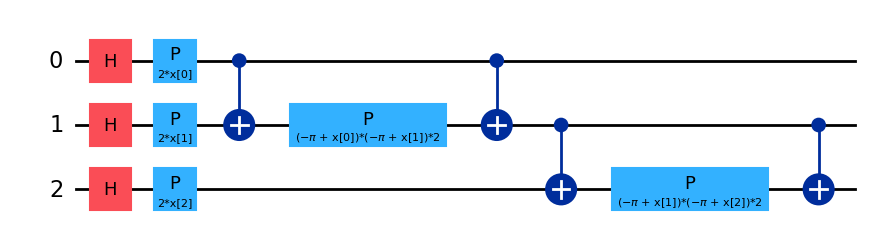

In [29]:
from qiskit.circuit.library import zz_feature_map

num_features = X_q_train_scaled.shape[1]

feature_map = zz_feature_map(
    feature_dimension=num_features,
    reps=1,
    entanglement="linear"
)

print("Number of qubits:", feature_map.num_qubits)
print("Circuit depth:", feature_map.depth())

feature_map.draw("mpl")

créer le FidelityQuantumKernel

In [30]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

print("Quantum kernel created successfully.")

Quantum kernel created successfully.


calculer une petite matrice kernel

In [31]:
kernel_matrix_train = quantum_kernel.evaluate(
    x_vec=X_q_train_scaled
)

print("Kernel matrix shape:", kernel_matrix_train.shape)
print(kernel_matrix_train[:5, :5])

Kernel matrix shape: (20, 20)
[[1.00000000e+00 1.67872287e-01 7.55545842e-01 3.52206303e-02
  1.78619974e-02]
 [1.67872287e-01 1.00000000e+00 2.83236647e-01 5.54959943e-01
  3.62768364e-02]
 [7.55545842e-01 2.83236647e-01 1.00000000e+00 1.28229865e-01
  1.72503704e-04]
 [3.52206303e-02 5.54959943e-01 1.28229865e-01 1.00000000e+00
  6.63749385e-02]
 [1.78619974e-02 3.62768364e-02 1.72503704e-04 6.63749385e-02
  1.00000000e+00]]


entraîner le QSVC

In [32]:
from qiskit_machine_learning.algorithms import QSVC

qsvc = QSVC(
    quantum_kernel=quantum_kernel
)

qsvc.fit(
    X_q_train_scaled,
    y_q_train
)

print("QSVC trained successfully.")

QSVC trained successfully.


prédire sur la validation

In [33]:
y_q_pred = qsvc.predict(X_q_val_scaled)

print("First predictions:")
print(y_q_pred[:20])

First predictions:
[1 0 1 0 1 0 0 1 1 1 0 1 0 0 0 1 0 1 1 1]


In [34]:
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    recall_score
)

print(
    "Balanced Accuracy:",
    balanced_accuracy_score(y_q_val, y_q_pred)
)

print(
    "F1:",
    f1_score(y_q_val, y_q_pred)
)

print(
    "Recall (High Vol):",
    recall_score(y_q_val, y_q_pred)
)

Balanced Accuracy: 0.6217532467532467
F1: 0.732824427480916
Recall (High Vol): 0.8571428571428571


In [35]:
y_q_score = qsvc.decision_function(X_q_val_scaled)

print(
    "ROC-AUC:",
    roc_auc_score(y_q_val, y_q_score)
)

ROC-AUC: 0.6964285714285714


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    recall_score,
    roc_auc_score
)
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel

quantum_results = []

for N in N_values:

    for window_id, idx in enumerate(window_indices[N], start=1):

        # Same chronological window used by the classical model
        window = train_thin.loc[idx]

        X_train_window = window[feature_cols]
        y_train_window = window["high_vol"].astype(int)

        X_val_window = val_thin[feature_cols]
        y_val_window = val_thin["high_vol"].astype(int)

        # Quantum-friendly scaling fitted ONLY on this training window
        q_scaler = MinMaxScaler(
            feature_range=(0, np.pi),
            clip=True
        )

        X_train_q = q_scaler.fit_transform(X_train_window)
        X_val_q = q_scaler.transform(X_val_window)

        # New kernel instance
        q_kernel = FidelityQuantumKernel(
            feature_map=feature_map
        )

        # Quantum SVM
        qsvc_model = QSVC(
            quantum_kernel=q_kernel
        )

        qsvc_model.fit(
            X_train_q,
            y_train_window
        )

        # Predictions
        y_pred_q = qsvc_model.predict(X_val_q)
        y_score_q = qsvc_model.decision_function(X_val_q)

        quantum_results.append({
            "N": N,
            "window": window_id,
            "start": window.index.min(),
            "end": window.index.max(),
            "train_high_vol_rate": y_train_window.mean(),
            "balanced_accuracy": balanced_accuracy_score(
                y_val_window, y_pred_q
            ),
            "roc_auc": roc_auc_score(
                y_val_window, y_score_q
            ),
            "f1": f1_score(
                y_val_window, y_pred_q
            ),
            "recall_high_vol": recall_score(
                y_val_window, y_pred_q
            )
        })

        print(f"Finished N={N}, window={window_id}")

quantum_results_df = pd.DataFrame(quantum_results)

quantum_results_df

Finished N=20, window=1
Finished N=20, window=2
Finished N=20, window=3
Finished N=50, window=1
Finished N=50, window=2
Finished N=50, window=3
Finished N=100, window=1
Finished N=100, window=2
Finished N=100, window=3
Finished N=200, window=1
Finished N=200, window=2


In [ ]:
quantum_summary_df = (
    quantum_results_df
    .groupby("N")
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        recall_mean=("recall_high_vol", "mean"),
        recall_std=("recall_high_vol", "std")
    )
    .reset_index()
)

quantum_summary_df

In [ ]:
comparison_df = pd.DataFrame({
    "N": summary_df["N"],

    "classical_bal_acc_mean":
        summary_df["balanced_accuracy_mean"],

    "classical_bal_acc_std":
        summary_df["balanced_accuracy_std"],

    "quantum_bal_acc_mean":
        quantum_summary_df["balanced_accuracy_mean"],

    "quantum_bal_acc_std":
        quantum_summary_df["balanced_accuracy_std"],

    "classical_auc_mean":
        summary_df["roc_auc_mean"],

    "quantum_auc_mean":
        quantum_summary_df["roc_auc_mean"]
})

comparison_df

In [ ]:
quantum_results_df.to_csv(
    "qregime_quantum_window_results.csv",
    index=False
)

quantum_summary_df.to_csv(
    "qregime_quantum_summary.csv",
    index=False
)

comparison_df.to_csv(
    "qregime_classical_vs_quantum.csv",
    index=False
)

print("Saved quantum results and comparison.")

créer la deuxième feature map

In [ ]:
from qiskit.circuit.library import zz_feature_map

feature_map_2 = zz_feature_map(
    feature_dimension=len(feature_cols),
    reps=2,
    entanglement="full"
)

print("Number of qubits:", feature_map_2.num_qubits)
print("Circuit depth:", feature_map_2.depth())

feature_map_2.draw("mpl")

QSVC avec Feature Map 2 sur toutes les fenêtres

In [ ]:
quantum_results_2 = []

for N in N_values:

    for window_id, idx in enumerate(window_indices[N], start=1):

        window = train_thin.loc[idx]

        X_train_window = window[feature_cols]
        y_train_window = window["high_vol"].astype(int)

        X_val_window = val_thin[feature_cols]
        y_val_window = val_thin["high_vol"].astype(int)

        # Same preprocessing strategy
        q_scaler = MinMaxScaler(
            feature_range=(0, np.pi),
            clip=True
        )

        X_train_q = q_scaler.fit_transform(X_train_window)
        X_val_q = q_scaler.transform(X_val_window)

        # Quantum kernel using Feature Map 2
        q_kernel_2 = FidelityQuantumKernel(
            feature_map=feature_map_2
        )

        qsvc_model_2 = QSVC(
            quantum_kernel=q_kernel_2
        )

        qsvc_model_2.fit(
            X_train_q,
            y_train_window
        )

        y_pred_q2 = qsvc_model_2.predict(X_val_q)
        y_score_q2 = qsvc_model_2.decision_function(X_val_q)

        quantum_results_2.append({
            "N": N,
            "window": window_id,
            "start": window.index.min(),
            "end": window.index.max(),
            "balanced_accuracy": balanced_accuracy_score(
                y_val_window, y_pred_q2
            ),
            "roc_auc": roc_auc_score(
                y_val_window, y_score_q2
            ),
            "f1": f1_score(
                y_val_window, y_pred_q2
            ),
            "recall_high_vol": recall_score(
                y_val_window, y_pred_q2
            )
        })

        print(f"Finished N={N}, window={window_id}")

quantum_results_2_df = pd.DataFrame(quantum_results_2)

quantum_results_2_df

In [ ]:
quantum_summary_2_df = (
    quantum_results_2_df
    .groupby("N")
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        recall_mean=("recall_high_vol", "mean"),
        recall_std=("recall_high_vol", "std")
    )
    .reset_index()
)

quantum_summary_2_df

In [ ]:
final_comparison_df = pd.DataFrame({
    "N": summary_df["N"],

    "Classical_BA":
        summary_df["balanced_accuracy_mean"],

    "Quantum_Map1_BA":
        quantum_summary_df["balanced_accuracy_mean"],

    "Quantum_Map2_BA":
        quantum_summary_2_df["balanced_accuracy_mean"],

    "Classical_AUC":
        summary_df["roc_auc_mean"],

    "Quantum_Map1_AUC":
        quantum_summary_df["roc_auc_mean"],

    "Quantum_Map2_AUC":
        quantum_summary_2_df["roc_auc_mean"]
})

final_comparison_df

In [ ]:
matched_classical_results = []

for N in N_values:

    for window_id, idx in enumerate(window_indices[N], start=1):

        window = train_thin.loc[idx]

        X_train_window = window[feature_cols]
        y_train_window = window["high_vol"].astype(int)

        X_val_window = val_thin[feature_cols]
        y_val_window = val_thin["high_vol"].astype(int)

        # EXACT same scaling used for quantum
        scaler = MinMaxScaler(
            feature_range=(0, np.pi),
            clip=True
        )

        X_train_scaled = scaler.fit_transform(X_train_window)
        X_val_scaled = scaler.transform(X_val_window)

        # Classical RBF-SVM
        model = SVC(
            kernel="rbf",
            C=1,
            gamma="scale",
            class_weight="balanced",
            random_state=42
        )

        model.fit(X_train_scaled, y_train_window)

        y_pred = model.predict(X_val_scaled)
        y_score = model.decision_function(X_val_scaled)

        matched_classical_results.append({
            "N": N,
            "window": window_id,
            "balanced_accuracy": balanced_accuracy_score(
                y_val_window, y_pred
            ),
            "roc_auc": roc_auc_score(
                y_val_window, y_score
            ),
            "f1": f1_score(
                y_val_window, y_pred
            ),
            "recall_high_vol": recall_score(
                y_val_window, y_pred
            )
        })

        print(f"Finished N={N}, window={window_id}")

matched_classical_results_df = pd.DataFrame(
    matched_classical_results
)

matched_classical_results_df

In [3]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

bloomberg_1 = pd.read_csv(
    RAW_DIR / "2015-2010.csv"
)

bloomberg_2 = pd.read_csv(
    RAW_DIR / "2024-2015.csv"
)

bloomberg_1["Date"] = pd.to_datetime(
    bloomberg_1["Date"],
    format="%m/%d/%y"
)

bloomberg_2["Date"] = pd.to_datetime(
    bloomberg_2["Date"],
    format="%m/%d/%y"
)

bloomberg_vol = pd.concat(
    [bloomberg_1, bloomberg_2],
    ignore_index=True
)

bloomberg_vol = (
    bloomberg_vol
    .drop_duplicates(subset="Date", keep="first")
    .sort_values("Date")
    .reset_index(drop=True)
)

bloomberg_vol.to_csv(
    PROCESSED_DIR / "spx_bloomberg_gk_volatility.csv",
    index=False
)

print(bloomberg_vol.head())
print(bloomberg_vol.tail())
print("Shape:", bloomberg_vol.shape)
print("Date range:", bloomberg_vol["Date"].min(),
      "to",
      bloomberg_vol["Date"].max())

print("\nMissing values:")
print(bloomberg_vol.isna().sum())

        Date  SPX Index Hist Vol (5)  SPX Index Hist Vol (20)
0 2010-01-04                6.895809                 8.975828
1 2010-01-05                6.737916                 7.516543
2 2010-01-06                6.907034                 7.266088
3 2010-01-07                8.006896                 7.198322
4 2010-01-08                8.077482                 7.032808
           Date  SPX Index Hist Vol (5)  SPX Index Hist Vol (20)
3769 2024-12-24               17.694100                 9.809946
3770 2024-12-26               14.167424                 9.894881
3771 2024-12-27               14.460431                10.201456
3772 2024-12-30               11.182908                10.565475
3773 2024-12-31               10.412080                10.766583
Shape: (3774, 3)
Date range: 2010-01-04 00:00:00 to 2024-12-31 00:00:00

Missing values:
Date                       0
SPX Index Hist Vol (5)     0
SPX Index Hist Vol (20)    0
dtype: int64


In [4]:
print(bloomberg_vol.describe())

                             Date  SPX Index Hist Vol (5)  \
count                        3774             3774.000000   
mean   2017-07-01 21:42:38.346582               11.016495   
min           2010-01-04 00:00:00                2.389969   
25%           2013-10-02 06:00:00                6.972743   
50%           2017-07-01 12:00:00                9.352289   
75%           2021-03-31 18:00:00               13.204263   
max           2024-12-31 00:00:00               75.225632   
std                           NaN                6.426890   

       SPX Index Hist Vol (20)  
count              3774.000000  
mean                 11.359932  
min                   3.442357  
25%                   7.757199  
50%                   9.563872  
75%                  13.554909  
max                  53.722363  
std                   5.779029  


In [5]:
print(
    bloomberg_vol[
        ["SPX Index Hist Vol (5)", "SPX Index Hist Vol (20)"]
    ].corr()
)

                         SPX Index Hist Vol (5)  SPX Index Hist Vol (20)
SPX Index Hist Vol (5)                 1.000000                 0.830196
SPX Index Hist Vol (20)                0.830196                 1.000000


In [29]:
import numpy as np
import pandas as pd

# On repart du dataframe Yahoo déjà téléchargé : sp500
# Il doit contenir Open, High, Low, Close

gk_daily = (
    0.5 * np.log(sp500["High"] / sp500["Low"])**2
    - (2 * np.log(2) - 1) * np.log(sp500["Close"] / sp500["Open"])**2
)

sp500["gk_daily_var"] = gk_daily

sp500["gk_vol_5d_calc"] = (
    np.sqrt(
        sp500["gk_daily_var"]
        .rolling(window=5)
        .sum()
        * (252 / 5)
    )
    * 100
)

sp500[["Open", "High", "Low", "Close", "gk_vol_5d_calc"]].head(10)

Price,Open,High,Low,Close,gk_vol_5d_calc
Date,,,,,
2010-01-04,1116.560059,1133.869995,1116.560059,1132.989990,NaN
2010-01-05,1132.660034,1136.630005,1129.660034,1136.520020,NaN
2010-01-06,1135.709961,1139.189941,1133.949951,1137.140015,NaN
2010-01-07,1136.270020,1142.459961,1131.319946,1141.689941,NaN
2010-01-08,1140.520020,1145.390015,1136.219971,1144.979980,7.970557
2010-01-11,1145.959961,1149.739990,1142.020020,1146.979980,7.531101
2010-01-12,1143.810059,1143.810059,1131.770020,1136.219971,8.308136
2010-01-13,1137.310059,1148.400024,1133.180054,1145.680054,9.917974
2010-01-14,1145.680054,1150.410034,1143.800049,1148.459961,9.262989


In [30]:
comparison_gk = (
    sp500[["gk_vol_5d_calc"]]
    .reset_index()
    .merge(
        bloomberg_vol[
            ["Date", "SPX Index Hist Vol (5)"]
        ],
        on="Date",
        how="inner"
    )
)

comparison_gk = comparison_gk.dropna()

corr_same_day = comparison_gk[
    ["gk_vol_5d_calc", "SPX Index Hist Vol (5)"]
].corr().iloc[0, 1]

mae_same_day = np.mean(
    np.abs(
        comparison_gk["gk_vol_5d_calc"]
        - comparison_gk["SPX Index Hist Vol (5)"]
    )
)

print("Same-day correlation:", corr_same_day)
print("Same-day MAE:", mae_same_day)

comparison_gk.head(10)

Same-day correlation: 0.999965231518953
Same-day MAE: 0.16820321938145516


,Date,gk_vol_5d_calc,SPX Index Hist Vol (5)
4,2010-01-08,7.970557,8.077482
5,2010-01-11,7.531101,7.661832
6,2010-01-12,8.308136,8.449730
7,2010-01-13,9.917974,10.081274
8,2010-01-14,9.262989,9.414070
9,2010-01-15,10.205220,10.363180
10,2010-01-19,10.216670,10.355161
11,2010-01-20,11.752990,11.928864
12,2010-01-21,13.032453,13.199877
13,2010-01-22,14.329730,14.483879


In [31]:
shift_results = []

for shift in range(-5, 6):

    temp = comparison_gk.copy()

    temp["bloomberg_shifted"] = (
        temp["SPX Index Hist Vol (5)"].shift(shift)
    )

    valid = temp.dropna()

    corr = valid[
        ["gk_vol_5d_calc", "bloomberg_shifted"]
    ].corr().iloc[0, 1]

    mae = np.mean(
        np.abs(
            valid["gk_vol_5d_calc"]
            - valid["bloomberg_shifted"]
        )
    )

    shift_results.append({
        "shift": shift,
        "correlation": corr,
        "mae": mae
    })

shift_results_df = pd.DataFrame(shift_results)

shift_results_df.sort_values(
    "correlation",
    ascending=False
)

,shift,correlation,mae
5,0,0.999965,0.168203
4,-1,0.965582,1.010893
6,1,0.965475,1.011430
3,-2,0.914580,1.658194
7,2,0.914422,1.654207
2,-3,0.851850,2.226515
8,3,0.851651,2.220256
1,-4,0.787121,2.694960
9,4,0.786863,2.693113
0,-5,0.722872,3.088649
